In [ ]:
import ast
import pandas as pd
from datasets import load_dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date']= pd.to_datetime(df.job_posted_date)
import matplotlib.pyplot as plt
from adjustText import adjust_text

df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()

In [41]:
df_DA = df[df['job_title_short']== 'Data Analyst'].copy()
df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month

df_DA_explode = df_DA.explode('job_skills')
df_DA_pivot = df_DA_explode.pivot_table(index ='job_posted_month_no', columns = 'job_skills', aggfunc='size', fill_value=0)

df_DA_pivot.loc['Total'] = df_DA_pivot.sum()
df_DA_pivot = df_DA_pivot [df_DA_pivot.loc['Total'].sort_values(ascending= False).index]
df_DA_pivot = df_DA_pivot.drop('Total')

df_DA_pivot = df_DA_pivot.reset_index()
df_DA_pivot['job_posted_month'] = df_DA_pivot['job_posted_month_no'].apply(lambda x: pd.to_datetime (x, format='%m').strftime('%b'))
df_DA_pivot = df_DA_pivot.set_index('job_posted_month')
df_DA_pivot = df_DA_pivot.drop(columns = 'job_posted_month_no')




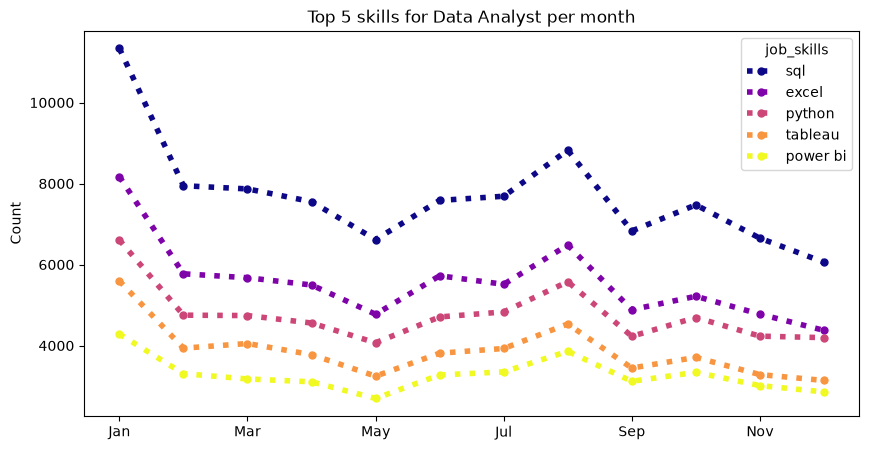

In [42]:
df_DA_pivot.iloc[:, :5].plot(
    kind = 'line',
       linewidth= 4,
       linestyle=':',
       colormap="plasma",
       marker = 'o',
       markersize= 5,
       figsize= (10, 5)

    
    )

plt.title('Top 5 skills for Data Analyst per month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()


In [43]:
df_exploded = df.explode('job_skills')

skill_stats = df_exploded.groupby('job_skills').agg(
    median_salary = ('salary_year_avg', 'median'),skill_count=('job_skills', 'count')
)

skill_count = 20
skill_stats = skill_stats.sort_values(by= 'skill_count', ascending=False).head(skill_count)

skill_stats

,median_salary,skill_count
job_skills,,
sql,120000.0,384849
python,125000.0,380909
aws,135000.0,145381
azure,125000.0,132527
r,119550.0,130892
tableau,111175.0,127213
excel,92500.0,127018
spark,140000.0,114609
power bi,102000.0,98147


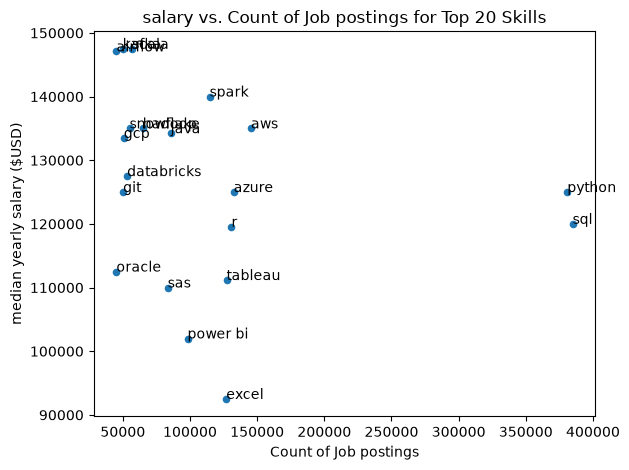

In [44]:
skill_stats.plot(kind = 'scatter', x= 'skill_count', y= 'median_salary')

for i, txt in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt)

plt.xlabel('Count of Job postings')
plt.ylabel ("median yearly salary ($USD)")
plt.title('salary vs. Count of Job postings for Top 20 Skills')
plt.tight_layout()
plt.show()

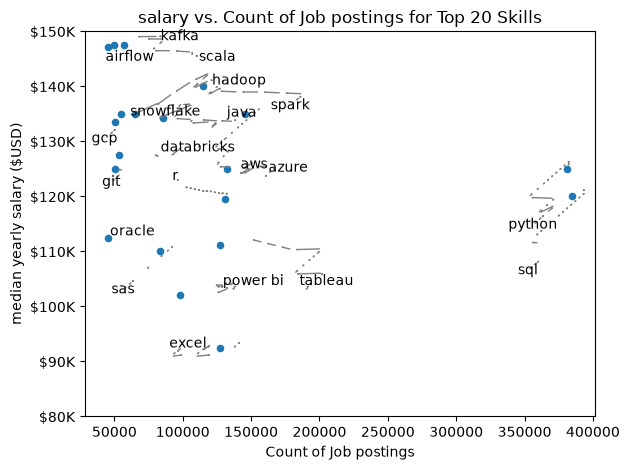

In [73]:
skill_stats.plot(kind = 'scatter', x= 'skill_count', y= 'median_salary')

texts=[]

for i, txt in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt))

    adjust_text(texts,
                force_text= 0.01,
                    force_static=0.01,
                    force_pull = 1,
                    max_move=(5, 5),
                    arrowprops=dict(arrowstyle="->", color='gray')
    )
    
    
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y , pos:f'${int(y/1000)}K'))

plt.xlabel('Count of Job postings')
plt.ylabel ("median yearly salary ($USD)")
plt.title(f'salary vs. Count of Job postings for Top 20 Skills')
plt.tight_layout()
plt.ylim(80000, 150000)
plt.show()